# Inteligencia Computacional — Guía de trabajos prácticos 1

## Ejercicio 1

> Implemente rutinas que permitan el entrenamiento y prueba de un perceptrón simple con una
> cantidad variable de entradas. Se deben tener en cuenta las siguientes capacidades:
>
> - lectura de los patrones de entrenamiento (entradas y salidas) desde un archivo en formato
>   texto separado por comas,
> - selección del criterio de finalización del entrenamiento y el número máximo de épocas,
> - selección de la tasa de aprendizaje,
> - prueba del perceptrón entrenado mediante archivos de texto con el mismo formato separado
>   por comas.
>
> Una vez obtenido dicho programa, pruébelo en la resolución del problema OR, utilizando los
> archivos de patrones `OR_trn.csv` y `OR_tst.csv` para el entrenamiento y la prueba,
> respectivamente. Los patrones que se proveen en estos archivos fueron generados a partir de
> los puntos $(1,1)$, $(1,-1)$, $(-1,1)$ y $(-1,-1)$ con pequeñas desviaciones aleatorias
> ($<5\,\%$) en torno a éstos. Recuerde que para que la prueba tenga validez se deben utilizar
> patrones nunca presentados en el entrenamiento; para esto se dispone de dos archivos de datos
> diferentes.


In [1]:
import numpy as np
from pathlib import Path
import pandas as pd

In [2]:
class Perceptron:
    def __init__(self, cantidad_entradas, tasa_aprendizaje=0.1, semilla=None):
        generador = np.random.default_rng(semilla)
        self.pesos = generador.uniform(-0.5, 0.5, cantidad_entradas)
        self.umbral = generador.uniform(-0.5, 0.5)
        self.tasa_aprendizaje = tasa_aprendizaje

    def entrada_neta(self, entradas):
        return np.dot(self.pesos, entradas) - self.umbral

    def activacion(self, entrada_neta):
        return 1 if entrada_neta >= 0 else -1

    def predecir(self, entradas):
        return self.activacion(self.entrada_neta(entradas))

    def entrenar_un_patron(self, entradas, salida_deseada):
        salida_obtenida = self.predecir(entradas)
        error = salida_deseada - salida_obtenida
        self.pesos = self.pesos + self.tasa_aprendizaje * error * entradas
        self.umbral = self.umbral - self.tasa_aprendizaje * error
        return error

    def entrenar(self, entradas_entrenamiento, salidas_deseadas, maximo_epocas,
                 criterio_de_corte="cero_errores"):
        errores_por_epoca = []
        historial_pesos = [(self.pesos.copy(), self.umbral)]

        for numero_de_epoca in range(maximo_epocas):
            errores_en_esta_epoca = 0

            for entradas, salida_deseada in zip(entradas_entrenamiento, salidas_deseadas):
                error = self.entrenar_un_patron(entradas, salida_deseada)
                if error != 0:
                    errores_en_esta_epoca += 1

            errores_por_epoca.append(errores_en_esta_epoca)
            historial_pesos.append((self.pesos.copy(), self.umbral))

            if criterio_de_corte == "cero_errores" and errores_en_esta_epoca == 0:
                break

        return errores_por_epoca, historial_pesos

    def probar(self, entradas_prueba, salidas_deseadas_prueba):
        cantidad_patrones = len(salidas_deseadas_prueba)
        cantidad_errores = 0

        for entradas, salida_deseada in zip(entradas_prueba, salidas_deseadas_prueba):
            if self.predecir(entradas) != salida_deseada:
                cantidad_errores += 1

        porcentaje_aciertos = 100 * (cantidad_patrones - cantidad_errores) / cantidad_patrones
        return porcentaje_aciertos, cantidad_errores

In [3]:
from src.data_loader import cargar_patrones

DIRECTORIO_DATASET = Path("Dataset")

tasa_aprendizaje = 0.1
semilla = 42
maximo_epocas = 100
criterio_de_corte = "cero_errores"

entradas_or, salidas_deseadas_or = cargar_patrones(DIRECTORIO_DATASET / "OR_trn.csv")
entradas_or_prueba, salidas_deseadas_or_prueba = cargar_patrones(DIRECTORIO_DATASET / "OR_tst.csv")

perceptron_or = Perceptron(
    cantidad_entradas=entradas_or.shape[1],
    tasa_aprendizaje=tasa_aprendizaje,
    semilla=semilla,
)

errores_por_epoca_or, historial_pesos_or = perceptron_or.entrenar(
    entradas_or,
    salidas_deseadas_or,
    maximo_epocas=maximo_epocas,
    criterio_de_corte=criterio_de_corte,
)

porcentaje_aciertos_or, cantidad_errores_or = perceptron_or.probar(
    entradas_or_prueba, salidas_deseadas_or_prueba
)

convergio = errores_por_epoca_or[-1] == 0
w1, w2 = perceptron_or.pesos
umbral = perceptron_or.umbral

pd.DataFrame(
    [
        ("Patrones de entrenamiento", len(salidas_deseadas_or)),
        ("Patrones de prueba", len(salidas_deseadas_or_prueba)),
        ("Entradas por patrón", entradas_or.shape[1]),
        ("Tasa de aprendizaje", tasa_aprendizaje),
        ("Criterio de corte", "cero errores" if convergio else "máximo de épocas"),
        ("Épocas utilizadas", f"{len(errores_por_epoca_or)} de {maximo_epocas}"),
        ("Errores por época", " → ".join(str(e) for e in errores_por_epoca_or)),
        ("w₁", round(w1, 4)),
        ("w₂", round(w2, 4)),
        ("Umbral (θ)", round(umbral, 4)),
        ("Recta de separación", f"x₂ = {-w1 / w2:.4f} x₁ + {umbral / w2:.4f}"),
        ("Aciertos en prueba",
         f"{porcentaje_aciertos_or:.1f} % ({cantidad_errores_or} errores sobre {len(salidas_deseadas_or_prueba)})"),
    ],
    columns=["Métrica", "Valor"],
)

,Métrica,Valor
0,Patrones de entrenamiento,2000
1,Patrones de prueba,200
2,Entradas por patrón,2
3,Tasa de aprendizaje,0.1
4,Criterio de corte,cero errores
5,Épocas utilizadas,2 de 100
6,Errores por época,6 → 0
7,w₁,0.2771
8,w₂,0.3378
9,Umbral (θ),-0.4414


### Conclusión del Ejercicio 1

El perceptrón resuelve el OR sin dificultad: **converge en 2 épocas y clasifica correctamente el
100 % de los patrones de prueba**, que nunca vio durante el entrenamiento. En la primera pasada se
equivoca en apenas 6 de los 2000 patrones y en la segunda ya no comete ninguno, por lo que el
criterio `cero_errores` corta mucho antes del máximo de 100 épocas.

El resultado es el esperado: los cuatro grupos de patrones están muy concentrados en torno a sus
vértices, con desviaciones menores al 5 %, y la clase $-1$ ocupa un único vértice. El problema es
**linealmente separable** y basta una recta para resolverlo.

**No memorizó, generalizó.** El 100 % se obtiene sobre un archivo independiente de 200 patrones que
la neurona nunca vio. Y memorizar es directamente imposible: el modelo tiene tres números
—$w_1$, $w_2$ y $\theta$— contra 2000 patrones de entrenamiento. Lo único que puede hacer con tres
números es encontrar la regla.

**Sobre el criterio de corte.** Que una época termine con cero errores no es una casualidad
afortunada sino un punto fijo: sin errores no hay correcciones, y sin correcciones los pesos al
final de la época son idénticos a los del comienzo. Se puede verificar comparando las dos últimas
entradas de `historial_pesos_or`.

**Sobre la tasa de aprendizaje.** Se ensayaron valores entre 0,001 y 1,0 y en todos los casos el
entrenamiento convergió en las mismas 2 épocas con 100 % de aciertos. La razón inmediata es que la
salida es $\operatorname{signo}(w_1x_1 + w_2x_2 - \theta)$ y el signo es invariante a escala:
multiplicar $w_1$, $w_2$ y $\theta$ por una constante positiva deja la recta exactamente en el
mismo lugar.

La afirmación precisa, sin embargo, es que **lo determinante es $\eta$ relativo al módulo de los
pesos iniciales**. Partiendo de $\mathbf{w}(0) = \mathbf{0}$ la tasa es un factor de escala puro y
todas las tasas dan literalmente la misma recta. Partiendo de pesos aleatorios en
$[-0{,}5;\ 0{,}5]$, en cambio, una tasa varios órdenes de magnitud menor deja las correcciones sin
fuerza para mover la frontera dentro del presupuesto de épocas: con $\eta = 10^{-6}$ el
entrenamiento **no converge** en 100 épocas y el acierto en prueba cae al 63,5 %.

Conviene notar además que **cada tasa converge a una recta distinta**, no a la misma reescalada:
todas resuelven el problema, pero con márgenes muy diferentes. La distancia del patrón de
entrenamiento más cercano a la frontera hallada va de 0,001 con $\eta = 0{,}001$ hasta 0,42 con
$\eta = 1$. El algoritmo se detiene apenas deja de haber errores, sin ninguna noción de margen, de
modo que puede quedarse con una recta que roza los datos.

**Sobre el máximo de épocas.** Tampoco es limitante acá, porque el criterio de cero errores se
activa mucho antes. Su verdadera utilidad aparece en el Ejercicio 2, donde el entrenamiento nunca
converge y el máximo de épocas pasa a ser el único criterio de corte efectivo.

## Ejercicio 2

> Implemente una rutina de graficación que permita visualizar, para el caso de dos
> entradas, los patrones utilizados y la recta de separación que se va ajustando durante
> el entrenamiento del perceptrón simple. Utilice dicha rutina para visualizar el
> entrenamiento en los problemas OR y XOR (utilizando los archivos de datos `OR_trn.csv`
> y `XOR_trn.csv`).

In [4]:
from src.graficos import graficar_y_animar_entrenamientos

entradas_xor, salidas_deseadas_xor = cargar_patrones(DIRECTORIO_DATASET / "XOR_trn.csv")

perceptron_xor = Perceptron(
    cantidad_entradas=entradas_xor.shape[1],
    tasa_aprendizaje=tasa_aprendizaje,
    semilla=semilla,
)

errores_por_epoca_xor, historial_pesos_xor = perceptron_xor.entrenar(
    entradas_xor,
    salidas_deseadas_xor,
    maximo_epocas=maximo_epocas,
    criterio_de_corte=criterio_de_corte,
)

pd.DataFrame(
    [
        ("Épocas utilizadas", f"{len(errores_por_epoca_xor)} de {maximo_epocas}"),
        ("Errores en la última época", errores_por_epoca_xor[-1]),
        ("Errores mínimos en alguna época", min(errores_por_epoca_xor)),
    ],
    columns=["Métrica", "Valor"],
)

,Métrica,Valor
0,Épocas utilizadas,100 de 100
1,Errores en la última época,829
2,Errores mínimos en alguna época,754


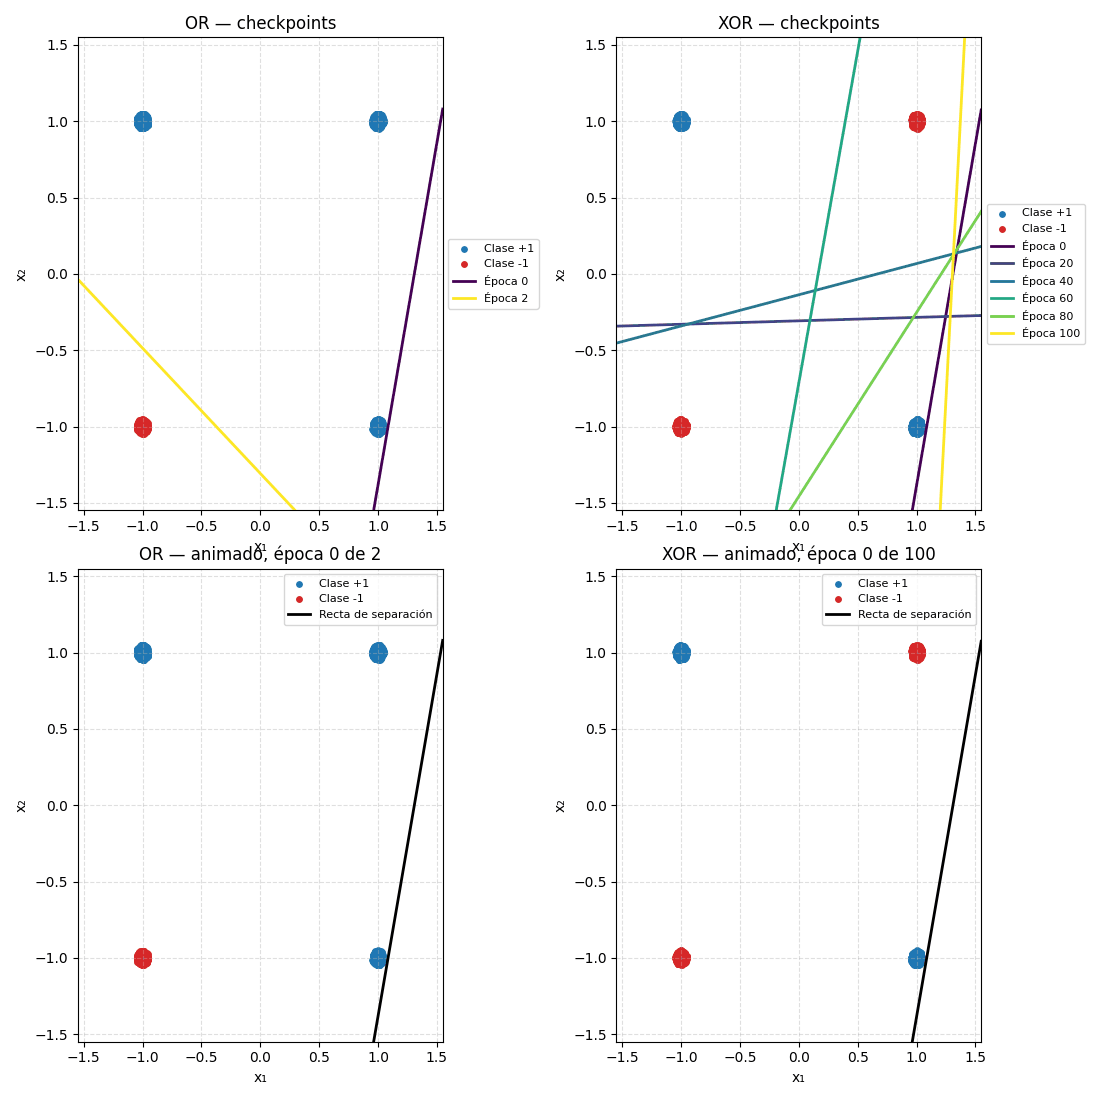

In [5]:
DIRECTORIO_GRAFICOS = Path("Graficos")

graficar_y_animar_entrenamientos(
    [
        (entradas_or, salidas_deseadas_or, historial_pesos_or, "OR"),
        (entradas_xor, salidas_deseadas_xor, historial_pesos_xor, "XOR"),
    ],
    ruta_gif=DIRECTORIO_GRAFICOS / "or_xor_entrenamiento.gif",
)

### Conclusión del Ejercicio 2

**OR.** Tanto en la versión estática (checkpoints) como en la animada se ve lo mismo que ya
mostraba el Ejercicio 1 con otra forma: la recta arranca en una posición aleatoria y en dos
saltos —uno por época— cae sobre una posición que separa los cuatro grupos sin error. El GIF
lo hace explícito: se mueve en el frame 1, se mueve una vez más en el frame 2, y a partir de
ahí queda inmóvil durante el resto de las épocas porque, como se argumentó antes, cero errores
implica cero correcciones.

**XOR.** Acá la diferencia es total. La recta nunca deja de moverse: en la versión estática los
checkpoints muestran posiciones completamente distintas entre sí, sin ninguna tendencia a
estabilizarse, y la animación confirma que ese movimiento continúa frame a frame hasta la
época 100 inclusive. El motivo es geométrico, no numérico: las cuatro combinaciones de XOR
ubican una clase en dos vértices opuestos de un cuadrado y la otra clase en los dos vértices
restantes, así que ninguna recta puede dejar a un lado únicamente los puntos de una clase. Sin
una recta que logre cero errores, nunca se llega al punto fijo del Ejercicio 1: en cada época
hay entre el 37,7 % y el 41,4 % de patrones mal clasificados (754 a 829 de los 2000), los pesos
se siguen corrigiendo, y el criterio `cero_errores` nunca corta —el entrenamiento termina
únicamente porque se alcanzó el `maximo_epocas` de 100. Esta es la situación que ya anticipaba
la conclusión del Ejercicio 1: acá el máximo de épocas deja de ser un techo teórico y pasa a
ser el criterio de corte real.

## Ejercicio 3

> Repita el entrenamiento realizado para el caso del OR, pero entrenando con los archivos
> `OR_50_trn.csv` y `OR_90_trn.csv`, y sus correspondientes `OR_50_tst.csv` y
> `OR_90_tst.csv` para test. Estos datos fueron generados de la misma forma que los usados
> en el primer ejercicio, pero utilizando desviaciones aleatorias de 50 % y 90 %,
> respectivamente. Analice y discuta los resultados.

In [6]:
casos_ruido = [
    ("5 %", DIRECTORIO_DATASET / "OR_trn.csv", DIRECTORIO_DATASET / "OR_tst.csv"),
    ("50 %", DIRECTORIO_DATASET / "OR_50_trn.csv", DIRECTORIO_DATASET / "OR_50_tst.csv"),
    ("90 %", DIRECTORIO_DATASET / "OR_90_trn.csv", DIRECTORIO_DATASET / "OR_90_tst.csv"),
]

entrenamientos_ruido = {}
filas_resumen_ruido = []

for desviacion, ruta_trn, ruta_tst in casos_ruido:
    entradas_trn, salidas_trn = cargar_patrones(ruta_trn)
    entradas_tst, salidas_tst = cargar_patrones(ruta_tst)

    perceptron = Perceptron(
        cantidad_entradas=entradas_trn.shape[1],
        tasa_aprendizaje=tasa_aprendizaje,
        semilla=semilla,
    )
    errores_por_epoca, historial_pesos = perceptron.entrenar(
        entradas_trn, salidas_trn,
        maximo_epocas=maximo_epocas,
        criterio_de_corte=criterio_de_corte,
    )
    porcentaje_aciertos, cantidad_errores = perceptron.probar(entradas_tst, salidas_tst)

    entrenamientos_ruido[desviacion] = (entradas_trn, salidas_trn, historial_pesos)

    filas_resumen_ruido.append((
        desviacion,
        len(salidas_trn),
        f"{len(errores_por_epoca)} de {maximo_epocas}",
        "sí" if errores_por_epoca[-1] == 0 else "no",
        errores_por_epoca[0],
        errores_por_epoca[-1],
        f"{porcentaje_aciertos:.1f} % ({cantidad_errores} errores sobre {len(salidas_tst)})",
    ))

pd.DataFrame(
    filas_resumen_ruido,
    columns=[
        "Desviación", "Patrones de entrenamiento", "Épocas utilizadas", "Convergió",
        "Errores en la 1ª época", "Errores en la última época", "Aciertos en prueba",
    ],
)

,Desviación,Patrones de entrenamiento,Épocas utilizadas,Convergió,Errores en la 1ª época,Errores en la última época,Aciertos en prueba
0,5 %,2000,2 de 100,sí,6,0,100.0 % (0 errores sobre 200)
1,50 %,1000,2 de 100,sí,8,0,100.0 % (0 errores sobre 200)
2,90 %,1000,100 de 100,no,90,58,93.0 % (14 errores sobre 200)


In [ ]:
graficar_y_animar_entrenamientos(
    [
        (entradas_trn, salidas_trn, historial_pesos, f"OR ±{desviacion}")
        for desviacion, (entradas_trn, salidas_trn, historial_pesos) in entrenamientos_ruido.items()
    ],
    ruta_gif=DIRECTORIO_GRAFICOS / "or_ruido_entrenamiento.gif",
)

### Conclusión del Ejercicio 3

**±50 % se comporta igual que ±5 %.** Pese a que la desviación es diez veces mayor, el
perceptrón converge en las mismas 2 épocas y clasifica el 100 % de los patrones de prueba. La
recta que encuentra no es la misma que con ±5 % —tiene que dejar un margen mucho más amplio—,
pero el problema sigue siendo **linealmente separable**: los cuatro grupos, aunque más
dispersos, todavía no se tocan entre sí. Se ve claramente en la grilla: la nube de puntos de
±50 % ocupa gran parte del plano, pero conserva cuatro regiones limpias sin superposición.

**±90 % rompe la separabilidad lineal.** Acá el entrenamiento nunca llega a cero errores —se
mueve entre 52 y 90 patrones mal clasificados de los 1000, y termina únicamente porque se
alcanza el `maximo_epocas` de 100— y en el gráfico se entiende por qué: con una desviación tan
grande los cuatro grupos se superponen, y aparecen patrones de la clase $+1$ mezclados entre los
de la clase $-1$ y viceversa. Ninguna recta puede separar algo que ya no está separado en los
datos. Es exactamente el mismo fenómeno geométrico del XOR en el Ejercicio 2 —ninguna recta,
sin importar cuánto se mueva, logra cero errores—, solo que acá el problema no es la forma en
que se combinan las clases sino el ruido: el ±90 % alcanza a invadir el espacio de la clase
opuesta.

**Aun así, no es un fracaso total.** Con un problema no separable el perceptrón no tiene una
solución exacta a la que converger, así que sigue corrigiendo pesos hasta el final —el
`criterio_de_corte` de cero errores nunca se activa—, pero la recta que va dejando en el camino
sigue siendo razonable: 93,0 % de aciertos en prueba (14 errores sobre 200). El algoritmo no
encuentra la frontera perfecta porque no existe, pero encuentra la mejor frontera lineal
disponible, que sigue clasificando bien a la gran mayoría de los patrones.